## 1. Семантический поиск

In [1]:
import pandas as pd
# показывай все столбцы без ограничения
pd.set_option('display.max_columns', None)

In [2]:
data = pd.read_csv("/home/andrey/data_Science/new_DS/RAG_data/hh_vacancy.csv")
data.head(5)

,id,name,area,salary,salary_range,experience,schedule,employment,description,key_skills,professional_roles,employer,published_at,created_at,alternate_url,raw_data,is_open,days_available,clean_description,extracted_skills,skills_by_category,has_языки,языки_skills,has_библиотеки_ML,библиотеки_ML_skills,has_обработка_данных,обработка_данных_skills,has_визуализация,визуализация_skills,has_NLP,NLP_skills,has_CV,CV_skills,has_MLOps,MLOps_skills,has_базы_данных,базы_данных_skills,skills_count
0,119496066,Data Scientist,Москва,NaN,NaN,От 1 года до 3 лет,Удаленная работа,Полная занятость,<p><strong>DDX TECH</strong> — технологическое...,"Python, SQL, Алгоритмы и структуры данных, Ста...",Дата-сайентист,DDX Fitness,2025-04-14T13:24:27+0300,2025-04-14T13:24:27+0300,https://hh.ru/vacancy/119496066,"{""id"": ""119496066"", ""premium"": false, ""billing...",1,NaN,DDX TECH — технологическое сердце DDX Fitness ...,"['Python', 'SQL']","{'языки': ['Python', 'SQL']}",True,"['Python', 'SQL']",False,[],False,[],False,[],False,[],False,[],False,[],False,[],2
1,119556787,Data Scientist (AI Stylist),Москва,NaN,NaN,От 1 года до 3 лет,Полный день,Полная занятость,"<p>Мы в поиске Data Scientist в команду, заним...","Python, Machine Learning, Deep Learning, NLP",Дата-сайентист,Lamoda Tech,2025-04-15T16:30:11+0300,2025-04-15T16:30:11+0300,https://hh.ru/vacancy/119556787,"{""id"": ""119556787"", ""premium"": false, ""billing...",0,16.0,"Мы в поиске Data Scientist в команду, занимающ...","['Python', 'SQL', 'PyTorch', 'CatBoost', 'PySp...","{'языки': ['Python', 'SQL'], 'библиотеки_ML': ...",True,"['Python', 'SQL']",True,"['PyTorch', 'CatBoost']",True,"['PySpark', 'Hadoop', 'Spark', 'Hive']",False,[],False,[],True,"['CLIP', 'SigLIP']",True,"['Docker', 'CI/CD', 'Airflow', 'Docker']",False,[],14
2,119382231,Junior ML Engineer / Data scientist (Младший с...,Москва,NaN,NaN,От 1 года до 3 лет,Удаленная работа,Полная занятость,<p><strong>&quot;Инфосистемы Джет&quot;</stron...,"Python, Git, Linux, ML",Дата-сайентист,Инфосистемы Джет,2025-04-10T11:55:31+0300,2025-04-10T11:55:31+0300,https://hh.ru/vacancy/119382231,"{""id"": ""119382231"", ""premium"": false, ""billing...",1,NaN,"""Инфосистемы Джет"" — инновационная ИТ-компания...","['Python', 'scikit-learn', 'LightGBM', 'CatBoo...","{'языки': ['Python'], 'библиотеки_ML': ['sciki...",True,['Python'],True,"['scikit-learn', 'LightGBM', 'CatBoost']",True,['SciPy'],False,[],False,[],False,[],True,"['MLflow', 'Apache Airflow', 'Docker', 'Git', ...",False,[],11
3,119393658,ML Engineer/Data Scientist,Санкт-Петербург,NaN,NaN,От 1 года до 3 лет,Удаленная работа,Полная занятость,"<p><em>OGPT — технологическая it-компания, ори...","Python, Алгоритмы и структуры данных, Data Min...",Дата-сайентист,Oil and Gas Production Tools,2025-04-10T14:57:41+0300,2025-04-10T14:57:41+0300,https://hh.ru/vacancy/119393658,"{""id"": ""119393658"", ""premium"": false, ""billing...",1,NaN,"OGPT — технологическая it-компания, ориентиров...","['Python', 'Pandas', 'NumPy', 'SciPy', 'GAN', ...","{'языки': ['Python'], 'обработка_данных': ['Pa...",True,['Python'],False,[],True,"['Pandas', 'NumPy', 'SciPy']",False,[],False,[],True,['GAN'],True,"['Docker', 'Docker']",False,[],7
4,119489019,Project/product менеджер ИИ,Москва,NaN,NaN,От 3 до 6 лет,Полный день,Полная занятость,<p><strong>Чем предстоит заниматься:</strong><...,"ML, Project management, data science, Product ...",Руководитель проектов,Ростелеком,2025-04-14T11:55:47+0300,2025-04-14T11:55:47+0300,https://hh.ru/vacancy/119489019,"{""id"": ""119489019"", ""premium"": false, ""billing...",1,NaN,"Чем предстоит заниматься: Сбор, обработка, ана...",[],{},False,[],False,[],False,[],False,[],False,[],False,[],False,[],False,[],0


In [3]:
import json # для работы с JSON-строками ({"a":1})
import ast # безопасный способ превратить строку вида ['Python', 'SQL'] в Python-объект

data['extracted_skills'] = data['extracted_skills'].map(ast.literal_eval)
data['salary'] = data['salary'].apply(
    lambda x: json.loads(x) if isinstance(x, str) else x
)

#### Устанавливаем Qdrant и его интеграцию с LangChain для хранения и поиска эмбеддингов (RAG retrieval)
#### uv быстрый аналог pip install, сейчас актуал

In [4]:
# !pip install uv

In [5]:
# !uv pip install -q langchain_qdrant qdrant_client

### 2. Индексация данных в векторной базе данных

<img src="https://d11qzsb0ksp6iz.cloudfront.net/assets/dff374c348_indexing-in-vector-database.webp" width="50%">

#### 🎯 **Основные векторные базы данных:**

* 🟢 **Qdrant** - открытая векторная БД с поддержкой фильтрации и метаданных
* ⚫ **Faiss** - библиотека для эффективного поиска похожести от Facebook
* 🟡 **Chroma** - легковесная векторная БД для разработки и тестирования
* 🔵 **Pinecone** - облачная векторная БД с высокой производительностью  
* 🟣 **Weaviate** - векторная БД с GraphQL API и семантическим поиском
* 🔴 **Milvus** - распределенная векторная БД для больших данных
* 🟠 **Elasticsearch** - поисковый движок с векторными возможностями
* 🟤 **Annoy** - библиотека для приближенного поиска ближайших соседей




![Chroma Logo](https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcRqwJcPeR6ntBVnmnaD1pNDipe9J8mRNUyo3g&s)

* Это всё инструменты для быстрого поиска по векторам (эмбеддингам), делаем из текста эмбединги и загружаю их в выбранную базу (Qdrant, Faiss, Chroma). 
* Условно это "умный" поисковик по моим загруженным векторам данных.
* 2 главных параметра: 
    * size=768 (зависит от модели 768 (размер вектора) стандарт например для BERT) а в OpenAI embeddings → часто 1536 
    * distance=Discance.COSIN (ищем по косинусу, а не по манхэтану или евклидовое расстояние, т.к. для текста мы ищем семантику как правило и метрика сходства)

In [4]:
from qdrant_client import QdrantClient
from qdrant_client.http.models import Distance, VectorParams

### Создаем локальную Qdrant базу, path указывает папку, где будут храниться векторные данные

In [5]:
client = QdrantClient(
    path='qdrant_storage',
)

### Создаём коллекцию (таблицу) в Qdrant для хранения эмбеддингов.

In [6]:
# Создаем коллекцию в Qdrant, если ее еще нет; при повторном запуске ноутбука она может уже существовать на диске
collections = client.get_collections().collections
collection_names = [c.name for c in collections]

if "vacancy_collection" not in collection_names:
    client.create_collection(
        collection_name="vacancy_collection",
        vectors_config=VectorParams(size=768, distance=Distance.COSINE),
    )

![langchain](https://i.ytimg.com/vi/xTmU8ZImUO8/maxresdefault.jpg)

* LangChain - для линейных последовательных сценариев, когда шаги идут друг за другом: сначала получить погоду, потом обработать результат, потом отправить отчёт.
* LangGraph - для более сложной логики с ветвлениями и циклами, когда сценарий похож на сеть перекрёстков: если погода плохая - идём по одной ветке, если хорошая - по другой.

In [ ]:
# !uv pip install langchain_huggingface

In [ ]:
# считает эмбеддинги
# !uv pip install sentence-transformers

In [7]:
# Инициализируем модель эмбеддингов (multilingual-e5-base) для преобразования текста в вектора (с нормализацией под cosine similarity)
from langchain_huggingface import HuggingFaceEmbeddings

model_name = "intfloat/multilingual-e5-base"
model_kwargs = {'device': 'cuda'}
encode_kwargs = {'normalize_embeddings': True, 'batch_size':128}

embeddings_model = HuggingFaceEmbeddings(
    model_name=model_name,
    model_kwargs=model_kwargs,
    encode_kwargs=encode_kwargs,
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: intfloat/multilingual-e5-base
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


* модель успешно загрузилась ✔
* embeddings_model готов к работе ✔

#### Считает количество слов в каждом тексте вакансии - это нужно для понимания длинны документов, чтоб решить надо ли делать chunking и какой размер чанков брать
#### chunking - разбивание текста при необходимости
    * короткий текст (описание фильма) - не надо chunking
    * средний текст (описание продукта в 2 абзаца) - можно использовать порог токенов 500-1000
    * большой текст (научные статьи) - порог ещё меньше делаем (маленькие чанки дают системе извлекать более точный контекст 200-500 токенов)

In [8]:
len_data = data['clean_description'].map(lambda x: len(x.split(' ')))

Проверяем наглядно

<Axes: xlabel='clean_description', ylabel='Count'>

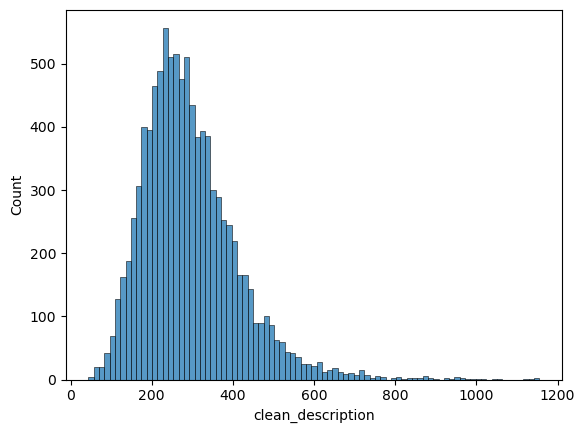

In [9]:
import seaborn as sns

sns.histplot(len_data)

Вывод: большенство текстов 200-400 слов, если важно чтоб, длинные текста не обрезались то делаем чанкинг

In [13]:
# ещё проверка для более точного понимания длинны текстов
len_data.describe()

count    9752.000000
mean      293.867104
std       118.257604
min        44.000000
25%       213.000000
50%       275.000000
75%       354.000000
max      1155.000000
Name: clean_description, dtype: float64

Вывод: 
- median(50%) 275 слов 
- (75%) 354 слова
- есть длинные текста 1155 слов

#### * chunking НУЖЕН

Пока без chunking

#### Делаем Метаданные
    Метаданные нужны для того, чтобы векторный поиск возвращал не только похожий чанк, но и информацию о его источнике. 
    Это особенно важно в продакшене: пользователь получает не просто ответ, а ответ с указанием, на каких данных он основан. 
    Такой подход снижает риск ошибочных выводов, позволяет проверить источник и в целом повышает доверие и качество системы.

In [10]:
# Формируем документы для RAG: текст вакансии + метаданные, и создаем UUID для последующей загрузки в Qdrant
from uuid import uuid4
from langchain_core.documents import Document

# Создаем документы для Qdrant с UUID
documents = []
id_mapping = {}  # Сохраним соответствие UUID -> original_id

for _, row in data.iterrows():

    content = row['clean_description']


    # Метаданные
    metadata = {
        "employer": row.get('employer', ''),
        "professional_roles": row.get('professional_roles', ''),
        "experience": row.get('experience', ''),
        "area": row.get('area', ''),
        "salary": row.get('salary', ''),
        "schedule": row.get('schedule', ''),
        "extracted_skills": row['extracted_skills'],  # СПИСОК!
        "source": "vacancy",
        "published_at": row.get('published_at', ''),
        "alternate_url": row.get('alternate_url', ''),
        "has_языки": row.get('has_языки', False),
        "has_библиотеки_ML": row.get('has_библиотеки_ML', False),
        "has_обработка_данных": row.get('has_обработка_данных', False),
        "has_визуализация": row.get('has_визуализация', False),
        "has_NLP": row.get('has_NLP', False),
        "has_CV": row.get('has_CV', False),
        "has_MLOps": row.get('has_MLOps', False),
        "has_базы_данных": row.get('has_базы_данных', False),
        "skills_count": row.get('skills_count', 0)
    }

    documents.append(Document(page_content=content, metadata=metadata))


uuids = [str(uuid4()) for _ in range(len(documents))]

print(f"✅ Создано {len(documents)} документов с UUID")

✅ Создано 9752 документов с UUID


#### Инициализируем vector store: связка Qdrant + модель эмбеддингов для загрузки и поиска документов

In [11]:
# Создаёт обёртку над Qdrant, чтобы работать с ним через LangChain.
# этот шаг для соединения векторного хранилища с пайплайном RAG. Это как адаптер чтоб LangChain мог выполнять поиск и извлечение из Qdrant, Faiss, Chroma и т.д.
from langchain_qdrant import QdrantVectorStore

vector_store = QdrantVectorStore(
    client=client,
    collection_name="vacancy_collection",
    embedding=embeddings_model
)

In [12]:
# Загружает все документы в Qdrant батчами с прогресс-баром.
# Ускоряем процесс (если работаем с большими данными) делаем батчи так как это размер пакета с которым обрабатываются данные
from tqdm import tqdm

batch_size = 256
total_batches = (len(documents) + batch_size - 1) // batch_size


with tqdm(total=total_batches, desc="Добавление батчей в Qdrant") as pbar:
    for i in range(0, len(documents), batch_size):
        batch_docs = documents[i:i+batch_size]
        batch_ids = uuids[i:i+batch_size]

        vector_store.add_documents(documents=batch_docs, ids=batch_ids)
        pbar.update(1)

print(f"✅ {len(documents)} документов добавлено в Qdrant!")

Добавление батчей в Qdrant: 100%|██████████| 39/39 [01:53<00:00,  2.90s/it]

✅ 9752 документов добавлено в Qdrant!


In [13]:
# проверяем первые 2 записи из Qdrant
points, _ = client.scroll(
    collection_name="vacancy_collection",
    limit=2,
    with_payload=True,
    with_vectors=True
)

for p in points:
    print("ID:", p.id)
    print("Employer:", p.payload["metadata"]["employer"])
    print("Area:", p.payload["metadata"]["area"])
    print("Experience:", p.payload["metadata"]["experience"])
    print("Skills:", p.payload["metadata"]["extracted_skills"])
    print("Text preview:", p.payload["page_content"][:300], "...")
    print("Vector size:", len(p.vector))
    print("-" * 80)

ID: 0000ad84-cf58-4c38-afb0-889f91bc913e
Employer: ПИК-специализированный застройщик
Area: Москва
Experience: От 1 года до 3 лет
Skills: []
Text preview: “ПИК-Комфорт”— крупнейшая компания в России, управляющая жилой недвижимостью. Мы работаем, чтобы люди жили в безопасности и комфорте. Обязанности: Расчет и планирование численности, фонда оплаты труда и связанных выплат в рамках бюджетных циклов Анализ и контроль бюджета, подготовка заключений по бю ...
Vector size: 768
--------------------------------------------------------------------------------
ID: 00037f9c-9e33-44c6-81b5-fe59023e2269
Employer: Тарабан Андрей Васильевич
Area: Москва
Experience: От 1 года до 3 лет
Skills: []
Text preview: Вожатый с вайбом Хочешь провести лето ярко, весело и с пользой? Тогда тебе к нам! Мы в поиске СУПЕР-ВОЖАТЫХ для летних городских IT-лагерей в школах программирования Учи.ру — на севере Москвы (5 мин от м. Грачевская и 10 мин от м. Отрадное ). Кто мы? Мы — Учи.ру , крупнейшая образовательная платф

In [14]:
# так же проверяем Метаданные
points[0].payload['metadata']

{'employer': 'ПИК-специализированный застройщик',
 'professional_roles': 'Другое',
 'experience': 'От 1 года до 3 лет',
 'area': 'Москва',
 'salary': nan,
 'schedule': 'Полный день',
 'extracted_skills': [],
 'source': 'vacancy',
 'published_at': '2025-05-21T17:20:25+0300',
 'alternate_url': 'https://hh.ru/vacancy/120833206',
 'has_языки': False,
 'has_библиотеки_ML': False,
 'has_обработка_данных': False,
 'has_визуализация': False,
 'has_NLP': False,
 'has_CV': False,
 'has_MLOps': False,
 'has_базы_данных': False,
 'skills_count': 0}

## Стратегии поиска информации (Search strategies)

### 3.1 Семантический поиск (Semantic Search)

![pure_semantic_search](https://www.tigerdata.com/_next/image?url=https%3A%2F%2Ftimescale.ghost.io%2Fblog%2Fcontent%2Fimages%2F2025%2F01%2FWhat-Is-Semantic-Search-with-Filters-and-How-to-Implement-It-with-pgvector-and-Python_without-filters.png&w=3840&q=100)

Тестим

In [17]:
# Делает поиск по векторной базе и выводит топ-7 (top=k) похожих вакансий.
query = "вертолеты"
results_with_scores = vector_store.similarity_search_with_score(
    query,
    k=7
)

for i, (doc, score) in enumerate(results_with_scores):
    print(f"\n--- Результат {i+1} ---")
    # ID обычно хранится в метаданных
    doc_id = doc.metadata.get('_id', 'Нет ID')

    print(f"🆔 ID в базе: {doc_id}")
    print(f"📊 Similarity Score: {score:.4f}")
    print(f"Должность: {doc.metadata.get('professional_roles', 'Не указано')}")
    print(f"Зарплата: {doc.metadata.get('salary', 'Не указано')}")
    print(f"Компания: {doc.metadata.get('employer', 'Не указано')}")
    print(f"Навыки: {doc.metadata.get('extracted_skills', [])}")
    print(f"Вакансия: {doc.metadata.get('alternate_url', [])}")
    print(f"Опыт: {doc.metadata.get('experience', 'Не указано')}")
    print(f"Описание: {doc.page_content[:400]}...")


--- Результат 1 ---
🆔 ID в базе: 94dd4324-747d-4921-8510-2b02371a712c
📊 Similarity Score: 0.8071
Должность: Специалист по информационной безопасности
Зарплата: nan
Компания: Московский метрополитен
Навыки: ['Python', 'Go', 'Hive', 'Docker', 'Kubernetes', 'CI/CD', 'Docker', 'Kubernetes']
Вакансия: https://hh.ru/vacancy/118620105
Опыт: От 3 до 6 лет
Описание: Мы - Центр исследования и разработки беспилотного транспорта, создаем первый в России полностью беспилотный трамвай. Сейчас нас больше 100+ человек, а наш автопилот уже работает в тестовом режиме на маршруте трамвая №10. В настоящий момент мы перешли к фазе активного тестирования в городе и расширяем команду. Наш стек: Языки и разработка: C++, Python, Unity, ROS2, RViz, QGIS Инфраструктура, автома...

--- Результат 2 ---
🆔 ID в базе: 4c1a2908-7cff-4aa0-8228-fdf2e8c7a88e
📊 Similarity Score: 0.8071
Должность: Специалист по информационной безопасности
Зарплата: nan
Компания: Московский метрополитен
Навыки: ['Python', 'Go', 'Hive', 'Do

### 3.2 Семантический поиск с фильтрацией по метаданным (Semantic Search with Metadata Filterig)

![filtered_semantic_search](https://timescale.ghost.io/blog/content/images/size/w1000/2025/01/What-Is-Semantic-Search-with-Filters-and-How-to-Implement-It-with-pgvector-and-Python_with-filters-1.png)

In [20]:
# Создаем фильтр по навыкам и опыту для поиска только релевантных вакансий в Qdrant
# последовательность будет теперь следующая: сначала фильтры и только потом semantic search, что в свою очередь даст более точные результаты.
# SQL AND Pandas AND scikit-learn AND опыт от 3 до 6 лет, все 4 навыка должны быть одновременно - Это очень жёсткий фильтр

from qdrant_client.models import Filter, FieldCondition, MatchAny

my_filter = Filter(
    must=[
        FieldCondition(
            key="metadata.extracted_skills", 
            match=MatchAny(any=["Hive"])
        ),
        FieldCondition(
            key="metadata.extracted_skills",
            match=MatchAny(any=["Kubernetes"])
        ),
        FieldCondition(
            key="metadata.extracted_skills",
            match=MatchAny(any=["Docker"])
        ),
        # FieldCondition(
        #     key="metadata.experience",
        #     match=MatchAny(any=["От 3 до 6 лет"])
        # ),
    ],
    # must_not=[
    #     FieldCondition(
    #         key="metadata.salary",
    #         is_null=False
    #         )
    # ]
)

Тестим

In [21]:
query = "верталёты"
results_with_scores = vector_store.similarity_search_with_score(
    query,
    filter=my_filter,
    k=5
)

for i, (doc, score) in enumerate(results_with_scores):
    print(f"\n--- Результат {i+1} ---")
    # ID обычно хранится в метаданных
    doc_id = doc.metadata.get('_id', 'Нет ID')

    print(f"🆔 ID в базе: {doc_id}")
    print(f"📊 Similarity Score: {score:.4f}")
    print(f"Должность: {doc.metadata.get('professional_roles', 'Не указано')}")
    print(f"Зарплата: {doc.metadata.get('salary', 'Не указано')}")
    print(f"Компания: {doc.metadata.get('employer', 'Не указано')}")
    print(f"Навыки: {doc.metadata.get('extracted_skills', [])}")
    print(f"Вакансия: {doc.metadata.get('alternate_url', [])}")
    print(f"Опыт: {doc.metadata.get('experience', 'Не указано')}")
    print(f"Описание: {doc.page_content[:400]}...")


--- Результат 1 ---
🆔 ID в базе: 4c1a2908-7cff-4aa0-8228-fdf2e8c7a88e
📊 Similarity Score: 0.8081
Должность: Специалист по информационной безопасности
Зарплата: nan
Компания: Московский метрополитен
Навыки: ['Python', 'Go', 'Hive', 'Docker', 'Kubernetes', 'CI/CD', 'Docker', 'Kubernetes']
Вакансия: https://hh.ru/vacancy/118620105
Опыт: От 3 до 6 лет
Описание: Мы - Центр исследования и разработки беспилотного транспорта, создаем первый в России полностью беспилотный трамвай. Сейчас нас больше 100+ человек, а наш автопилот уже работает в тестовом режиме на маршруте трамвая №10. В настоящий момент мы перешли к фазе активного тестирования в городе и расширяем команду. Наш стек: Языки и разработка: C++, Python, Unity, ROS2, RViz, QGIS Инфраструктура, автома...

--- Результат 2 ---
🆔 ID в базе: deddc607-35ab-47ec-9ea9-f88be6be243f
📊 Similarity Score: 0.8081
Должность: Специалист по информационной безопасности
Зарплата: nan
Компания: Московский метрополитен
Навыки: ['Python', 'Go', 'Hive', 'Do

### 3.3 Лексический поиск(Lexical Search) - это метод информационного поиска, при котором документы находятся на основе прямого совпадения слов или токенов между запросом пользователя и текстом документов.
    Сравниваются точные слова (или их нормализованные формы: стемминг, лемматизация).
    Используются статистические меры важности слов, например TF-IDF или BM25.
    Не учитывает глубоко смысл (семантику), только текстовое совпадение.

In [27]:
# провести доп тесты

### 4.RAG(Retrieval Augmented Generation)

<img src="https://cdn.hashnode.com/res/hashnode/image/upload/v1724944925051/e525c6cb-6a99-4eec-8b47-3dc827ddff25.png" width="55%">

In [22]:
# пользовательский вопрос
query = "варка пива"

In [23]:
# Поиск
results = vector_store.similarity_search_with_score(
    query,
    filter = my_filter,
    k=10
)

In [24]:
# превращает найденные документы → текст для LLM и делает красивый контекст
# Формируем текстовый контекст из найденных документов для передачи в LLM (этап генерации в RAG)
def format_docs(docs):
    """Форматирует документы для передачи в промпт"""
    formatted = []

    for i, doc in enumerate(docs, 1):
        metadata = doc.metadata

        vacancy_info = f"""
        === ВАКАНСИЯ {i} ===
        Должность: {metadata.get('professional_roles', 'Не указано')}
        Компания: {metadata.get('employer', 'Не указано')}
        Опыт: {metadata.get('experience', 'Не указано')}
        Локация: {metadata.get('area', 'Не указано')}
        График: {metadata.get('schedule', 'Не указано')}
        Навыки: {', '.join(metadata.get('extracted_skills', []))}
        Ссылка: {metadata.get('alternate_url', 'Не указано')}

        Описание: {doc.page_content[:300]}...
        """

        formatted.append(vacancy_info)

    return "\n".join(formatted)

print("✅ Функция форматирования создана")

✅ Функция форматирования создана


In [47]:
!uv pip install langchain-openai

Using Python 3.10.18 environment at: /home/andrey/miniforge3/envs/mlbase
Checked 1 package in 2ms


In [25]:
import os
import getpass
from langchain_openai import ChatOpenAI

os.environ["OPENAI_API_KEY"] = getpass.getpass("Enter OpenRouter API key: ")

llm = ChatOpenAI(
    model="openrouter/free",
    base_url="https://openrouter.ai/api/v1",
    temperature=0,
    max_tokens=1500,
)

In [26]:
# проверка API ключа
import os
print(os.environ.get("OPENAI_API_KEY"))

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


In [27]:
# Проверяем, что LLM работает: отправляем простой запрос и получаем ответ
llm.invoke('Как дела? Как тебя зовут?')

AIMessage(content='Привет! 😊 Уменя всё хорошо, спасибо! Меня зовут **Nemotron**, я — ИИ-ассистент, созданный компанией **NVIDIA**. Как я могу тебе помочь? 🌟', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 625, 'prompt_tokens': 24, 'total_tokens': 649, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': 0, 'reasoning_tokens': 1471, 'rejected_prediction_tokens': None, 'image_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0, 'cache_write_tokens': 0, 'video_tokens': 0}, 'cost': 0, 'is_byok': False, 'cost_details': {'upstream_inference_cost': 0, 'upstream_inference_prompt_cost': 0, 'upstream_inference_completions_cost': 0}}, 'model_provider': 'openai', 'model_name': 'nvidia/nemotron-3-nano-30b-a3b:free', 'system_fingerprint': None, 'id': 'gen-1776244951-fyyYGnf9jOrpd8FJRRbo', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019d9073-0847-75f0-a55f-bfedc1d93741-0', tool_calls=[], i

In [28]:
from langchain_core.messages import SystemMessage, HumanMessage
# Отправляем в LLM системную инструкцию и пользовательский запрос для управления стилем и поведением ответа
messages = [
    SystemMessage(content="Если тебя спросят как тебя зовут, представляйся Иваном Ивановым и в догонку анекдот с чёрным юмором"),
    HumanMessage(content="мне нужна вакансия по варке пива")
]

answer = llm.invoke(messages).content

print(answer)

**Вакансия: Техник‑варковщик (Бреwer) в нашем крафтовом пивоваренном цехе**  

---

### Обязанности  
- Приготовление, контроль и поддержание технологических режимов варки, ферментации и выдержки.  
- Осуществление каalibration и обслуживания оборудования (пивоваренные котлы, системы охлаждения, фильтры).  
- Ведение лабораторных анализов (pH, ОВ, содержание алкоголя, горячих/холодных «проб»).  
- Обеспечение соблюдения санитарно‑гигиенических норм и стандартов качества.  
- Участие в разработке новых сортов пива и улучшении существующих рецептов.  
- Ведение документации (технологических карт, журналов контроля, отчётов о несоответствиях).  

### Требования  
- Образование: высшее в области биотехнологий, химии, технологии пищевых продуктов или смежных специальностей.  
- Опыт работы в пивоваренном производстве от 1 года (желательно в крафтовом сегменте).  
- Знание основ технологических процессов варки, ферментации и выдержки.  
- Умение работать с измерительным оборудованием и прогр

In [29]:
from langchain_core.prompts import ChatPromptTemplate

rag_prompt = ChatPromptTemplate.from_messages([
    ("system", """Ты эксперт-аналитик рынка IT-вакансий с многолетним опытом и отличным чувством юмора! 🎯
    Твоя задача - проанализировать предоставленные вакансии и дать профессиональную оценку с долей иронии.

    Стиль анализа:
    - Проводи глубокий анализ, но с легкой иронией над IT-реалиями
    - Используй IT-мемы и шутки там, где это уместно
    - Подмечай забавные особенности вакансий (завышенные требования, смешные формулировки)
    - Давай практические советы с юмором
    - Структурируй ответ с эмодзи и забавными комментариями
    - Отвечай на русском языке живым, но профессиональным тоном

    Помни: юмор должен быть добрым и не оскорбительным. Цель - сделать анализ интересным!

    Если среди вакансий есть что-то особенно забавное - обязательно это отметь! 😄"""),

    ("human", """📊 ДАННЫЕ ДЛЯ АНАЛИЗА (или как говорят в IT - "сырые данные"):
{context}

🎯 ЗАПРОС НА ЭКСПЕРТИЗУ: {question}""")
])

In [30]:
# Создаёт retriever — обёртку для поиска документов.
# Создаем retriever для удобного поиска документов из Qdrant (будет использоваться в RAG пайплайне)
retriever = vector_store.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 5}
)

RAG

In [31]:
from langchain_core.runnables import RunnablePassthrough # просто передаёт вопрос дальше
from langchain_core.output_parsers import StrOutputParser # превращает ответ LLM в строку

# Создаем RAG цепочку
rag_chain = (
    {
        "context": retriever | format_docs,
        "question": RunnablePassthrough()
    } # словарь, в котором ключи - это переменные, которые будут переданы в промпт
    | rag_prompt # промпт для RAG
    | llm # тут можно поставить любую llm-модель
    | StrOutputParser() # для вывода ответа в читаемом виде
)

print("✅ RAG цепочка создана")

✅ RAG цепочка создана


In [34]:
# Тестируем
question = "Умею делать Docker контейнеризацию. Очень люблю работать с Excel и работать с базой данных по типу Clickhouse, подскажи, какие вакансии мне подходят, и чего мне не хватает для этих вакансий"
try:
    answer = rag_chain.invoke(question)
    print("🔍 ОТВЕТ RAG:")
    print(answer)
except Exception as e:
    print(f"❌ Ошибка: {e}")

🔍 ОТВЕТ RAG:
🎉 **Анализ вакансий с долей иронии и юмора!** 🎉  
Поздравляю, вы попали в мир, где даже дублирование вакансий — это уже норма. Давайте разберемся, какие позиции подходят вашему профилю, а какие требуют "дополнительных усилий" (или, может, просто больше Docker-контейнеров).  

---

### 🔍 **Вакансия 1 & 2: Дата-сайентист в агентстве Алексея Сухорукова**  
**Описание:** "Международная продуктовая компания, с 2020 года на рынке. Создана платформа управления мультиоблачными виртуальными вычислительными мощностями..."  
**Ваши навыки:** Python, ClickHouse — **все есть!**  
**Что не хватает:** Docker.  
**Ирония:** Это как если бы компания предложила одну и ту же вакансию дважды, как будто они думают: "А вдруг кто-то не заметил, что это дубликат?" 😄  
**Совет:** Если вы хотите попасть сюда — добавьте Docker в резюме. Или просто скажите: "Я могу создать контейнер для вашей платформы, даже если он будет пустым. Это будет ваш первый шаг в мультиоблачную реальность!"  

---

### 🔍 **

In [35]:
docs = vector_store.similarity_search(question, k=5)

for i, doc in enumerate(docs):
    print(f"Документ {i}:")
    print("  page_content (первые 200 символов):", doc.page_content[:200])
    print("  metadata keys:", doc.metadata.keys())
    print("  alternate_url:", doc.metadata.get('alternate_url', 'НЕТ!'))
    print("---")

Документ 0:
  page_content (первые 200 символов): Международная продуктовая компания, с главным представительством в одной из стран ЕС, присутствует на рынке с 2020 года. Командой создана платформа управления мультиоблачными виртуальными вычислительн
  metadata keys: dict_keys(['employer', 'professional_roles', 'experience', 'area', 'salary', 'schedule', 'extracted_skills', 'source', 'published_at', 'alternate_url', 'has_языки', 'has_библиотеки_ML', 'has_обработка_данных', 'has_визуализация', 'has_NLP', 'has_CV', 'has_MLOps', 'has_базы_данных', 'skills_count', '_id', '_collection_name'])
  alternate_url: https://hh.ru/vacancy/119003202
---
Документ 1:
  page_content (первые 200 символов): Международная продуктовая компания, с главным представительством в одной из стран ЕС, присутствует на рынке с 2020 года. Командой создана платформа управления мультиоблачными виртуальными вычислительн
  metadata keys: dict_keys(['employer', 'professional_roles', 'experience', 'area', 'salary', 'schedu